# Курсы ЦБ и оптимизация индикаторов

Ноутбук последовательно выполняет весь исследовательский pipeline:

1. загружает курсы ЦБ;
2. строит causal-признаки и targets;
3. задаёт пространства правил;
4. оптимизирует rule-based индикаторы через walk-forward;
5. продолжает WF для победивших G0/W1-архитектур с rolling train;
6. выбирает cadence и продолжает rolling WF ML-индикаторов G0/W1.


In [1]:
from datetime import date
from itertools import combinations, product
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.features import build_features
from src.indicator_optimization import optimize_indicator_library
from src.indicator_backtest import backtest_selected_indicators
from src.indicators import IndicatorCandidate, IndicatorRule, create_indicator_rules
from src.market_data import build_daily_market_panel, market_snapshot
from src.ml_backtest import run_ml_indicator_backtest
from src.fast_slow_analysis import analyze_fast_slow_signals
from src.visualization import (plot_benefit_distribution, plot_fast_slow_summary,
    plot_oos_uplift, plot_rate_panel, plot_signal_series)
from src.visualization import plot_fast_slow_summary, plot_signal_series
from src.outcomes import DEFAULT_HORIZONS, add_future_outcomes, outcome_columns
from src.target_evaluation import (
    evaluate_perfect_target_lift,
    evaluate_target_family_frequency,
)
from src.targets import build_targets, target_columns

START_DATE = date(2020, 1, 1)
END_DATE = date.today()
RECIPIENT_CURRENCIES = ("AMD", "KZT", "KGS", "TJS", "UZS")

# Проверяем несколько частот переобучения как полноценный параметр оптимизации.
FIRST_TEST_DATE = "2022-01-01"
TRAIN_WINDOW_MONTHS = 24
TEST_MONTHS_OPTIONS = (3, 6, 12)
INDICATOR_MIN_SIGNALS_PER_WEEK = 2.0
ENSEMBLE_LIFT_THRESHOLDS = (1.3,)
WINNER_WF_START = pd.Timestamp("2025-01-01")
WINNER_TARGET_FAMILIES = ("G0", "W1")
ML_VALIDATION_MONTHS = 12
ML_MODEL_TYPE = "hist_gradient_boosting" # "logistic_regression" "hist_gradient_boosting" "extra_trees"
ML_CURRENCIES = RECIPIENT_CURRENCIES #("KZT",)  # Для полного запуска: RECIPIENT_CURRENCIES
ML_TEST_MONTHS_OPTIONS = (12,)
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "cbr"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


## 1. Данные ЦБ

Номиналы приводятся к рублям за одну единицу валюты. `available_at` консервативно установлен на 00:00 следующего календарного дня. Сохраняется только базовое хранилище курсов, потому что оно является входом всего исследования.


In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE,
    end_date=END_DATE,
    currencies=CURRENCIES,
    raw_dir=RAW_DIR,
)
assert cbr_history["normalized_rate"].gt(0).all()
assert cbr_history["publication_timestamp_is_proxy"].all()
assert (cbr_history["available_at"] == cbr_history["effective_date"] + pd.Timedelta(days=1)).all()
pd.testing.assert_series_equal(
    cbr_history["normalized_rate"],
    cbr_history["raw_rate"] / cbr_history["nominal"],
    check_names=False,
)

rates = (
    cbr_history.pivot(index="available_at", columns="currency", values="normalized_rate")
    .reindex(columns=list(CURRENCIES))
    .sort_index()
)
rates.columns.name = None
rates.index.name = "available_at"
assert rates.notna().all().all()
assert rates.index.is_unique and rates.index.is_monotonic_increasing

market_panel = build_daily_market_panel(rates)
latest_snapshot = market_snapshot(market_panel, as_of=market_panel["available_at"].max())
assert set(latest_snapshot["currency"]) == set(CURRENCIES)

cbr_history.to_parquet(PROCESSED_DIR / "cbr_history_temporal.parquet", index=False)
rates.to_parquet(PROCESSED_DIR / "cbr_rates.parquet")
rates.to_csv(PROCESSED_DIR / "cbr_rates.csv")

pd.DataFrame({
    "publication_dates": [len(rates)],
    "first_available_at": [rates.index.min()],
    "last_available_at": [rates.index.max()],
    "currencies": [", ".join(rates.columns)],
})


,publication_dates,first_available_at,last_available_at,currencies
0,1644,2020-01-02,2026-09-05,"AMD, KZT, KGS, TJS, UZS, USD, EUR, CNY"


## 2. Features и targets

Признаки используют только текущие и прошлые значения. Future outcomes нужны исключительно для разметки. Оптимизация выполняется только на реальных днях публикации курсов пяти целевых валют.


In [3]:
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=DEFAULT_HORIZONS)
dataset, target_registry = build_targets(outcomes, horizons=DEFAULT_HORIZONS)

assert set(target_registry["horizon"]) == set(DEFAULT_HORIZONS)
assert target_registry["name"].isin(dataset.columns).all()
assert len(target_columns(dataset)) == len(target_registry)
assert outcome_columns(dataset)

update_rows = dataset.loc[
    dataset["is_update_day"] & dataset["currency"].isin(RECIPIENT_CURRENCIES)
].copy()
target_prevalence = (
    update_rows[["currency", *target_registry["name"].tolist()]]
    .melt(id_vars="currency", var_name="target", value_name="value")
    .dropna(subset=["value"])
    .groupby(["currency", "target"], as_index=False)
    .agg(observations=("value", "size"), positive_rate=("value", "mean"))
    .merge(
        target_registry[["name", "scenario", "family", "horizon"]],
        left_on="target", right_on="name", how="left", validate="many_to_one",
    )
    .drop(columns="name")
)
target_prevalence.pivot_table(
    index=["scenario", "family", "target", "horizon"],
    columns="currency", values="positive_rate",
).sort_index()


currency                                                                           AMD  \
scenario       family target                                         horizon             
GOOD_NOW       G0     target_g0_exact_min_h10d                       10        0.04284   
                      target_g0_exact_min_h1d                        1        0.274056   
                      target_g0_exact_min_h20d                       20       0.020345   
                      target_g0_exact_min_h3d                        3         0.12622   
                      target_g0_exact_min_h5d                        5        0.087858   
               G1     target_g1_regret_le_100bps_h10d                10       0.581296   
                      target_g1_regret_le_100bps_h1d                 1          0.9014   
                      target_g1_regret_le_100bps_h20d                20       0.463804   
                      target_g1_regret_le_100bps_h3d                 3        0.803778   
                      target_g1_regret_le_100bps_h5d                 5        0.712805   
                      target_g1_regret_le_25bps_h10d                 10       0.359413   
                      target_g1_regret_le_25bps_h1d                  1         0.71759   
                      target_g1_regret_le_25bps_h20d                 20       0.279141   
                      target_g1_regret_le_25bps_h3d                  3        0.552712   
                      target_g1_regret_le_25bps_h5d                  5        0.462195   
                      target_g1_regret_le_50bps_h10d                 10       0.459046   
                      target_g1_regret_le_50bps_h1d                  1        0.811929   
                      target_g1_regret_le_50bps_h20d                 20       0.360123   
                      target_g1_regret_le_50bps_h3d                  3        0.665448   
                      target_g1_regret_le_50bps_h5d                  5        0.571951   
WINDOW_CLOSING W0     target_w0_deterioration_75bps_h10d             10       0.408313   
                      target_w0_deterioration_75bps_h1d              1        0.136945   
                      target_w0_deterioration_75bps_h20d             20       0.457055   
                      target_w0_deterioration_75bps_h3d              3        0.243144   
                      target_w0_deterioration_75bps_h5d              5        0.332317   
               W1     target_w1_lowpct_0p15_deterioration_75bps_h10d 10        0.08038   
                      target_w1_lowpct_0p15_deterioration_75bps_h1d  1        0.027725   
                      target_w1_lowpct_0p15_deterioration_75bps_h20d 20       0.088945   
                      target_w1_lowpct_0p15_deterioration_75bps_h3d  3        0.051104   
                      target_w1_lowpct_0p15_deterioration_75bps_h5d  5        0.064394   

currency                                                                           KGS  \
scenario       family target                                         horizon             
GOOD_NOW       G0     target_g0_exact_min_h10d                       10       0.039168   
                      target_g0_exact_min_h1d                        1        0.277101   
                      target_g0_exact_min_h20d                       20       0.021578   
                      target_g0_exact_min_h3d                        3        0.133537   
                      target_g0_exact_min_h5d                        5        0.084808   
               G1     target_g1_regret_le_100bps_h10d                10       0.551956   
                      target_g1_regret_le_100bps_h1d                 1        0.903226   
                      target_g1_regret_le_100bps_h20d                20       0.443558   
                      target_g1_regret_le_100bps_h3d                 3        0.794637   
                      target_g1_regret_le_100bps_h5d                 5        0.704268   
                      target_g1_regret_

## 3. Теоретический lift таргетов до обучения моделей

Для каждой полной конфигурации `currency × exact target × horizon` рассматривается идеальный предиктор, который подаёт сигнал ровно на положительных наблюдениях. Его precision равна 1, precision случайного входа равна доле положительного класса, поэтому `ideal_lift_vs_random = 1 / random_precision`. Это верхняя теоретическая граница lift для бинарной метрики таргета, а не ожидаемое качество будущей модели. `positive_count` нужно рассматривать вместе с lift: редкий таргет автоматически получает высокий теоретический lift.


In [4]:
target_ideal_lift = evaluate_perfect_target_lift(
    update_rows,
    target_registry=target_registry,
)

target_ideal_lift_pivot = target_ideal_lift.pivot_table(
    index=["scenario", "target_family", "target", "horizon"],
    columns="currency",
    values="ideal_lift_vs_random",
).sort_index()
target_ideal_lift_pivot


currency                                                                                   AMD  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       23.342857   
                             target_g0_exact_min_h1d                        1         3.648889   
                             target_g0_exact_min_h20d                       20       49.151515   
                             target_g0_exact_min_h3d                        3         7.922705   
                             target_g0_exact_min_h5d                        5        11.381944   
               G1            target_g1_regret_le_100bps_h10d                10        1.720294   
                             target_g1_regret_le_100bps_h1d                 1         1.109386   
                             target_g1_regret_le_100bps_h20d                20        2.156085   
                             target_g1_regret_le_100bps_h3d                 3         1.244124   
                             target_g1_regret_le_100bps_h5d                 5         1.402908   
                             target_g1_regret_le_25bps_h10d                 10        2.782313   
                             target_g1_regret_le_25bps_h1d                  1         1.393554   
                             target_g1_regret_le_25bps_h20d                 20        3.582418   
                             target_g1_regret_le_25bps_h3d                  3         1.809261   
                             target_g1_regret_le_25bps_h5d                  5         2.163588   
                             target_g1_regret_le_50bps_h10d                 10        2.178429   
                             target_g1_regret_le_50bps_h1d                  1         1.231634   
                             target_g1_regret_le_50bps_h20d                 20        2.776831   
                             target_g1_regret_le_50bps_h3d                  3         1.502747   
                             target_g1_regret_le_50bps_h5d                  5         1.748401   
WINDOW_CLOSING W0            target_w0_deterioration_75bps_h10d             10        2.449102   
                             target_w0_deterioration_75bps_h1d              1         7.302222   
                             target_w0_deterioration_75bps_h20d             20        2.187919   
                             target_w0_deterioration_75bps_h3d              3         4.112782   
                             target_w0_deterioration_75bps_h5d              5         3.009174   
               W1            target_w1_lowpct_0p15_deterioration_75bps_h10d 10       12.440945   
                             target_w1_lowpct_0p15_deterioration_75bps_h1d  1        36.068182   
                             target_w1_lowpct_0p15_deterioration_75bps_h20d 20       11.242857   
                             target_w1_lowpct_0p15_deterioration_75bps_h3d  3        19.567901   
                             target_w1_lowpct_0p15_deterioration_75bps_h5d  5        15.529412   

currency                                                                                   KGS  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       25.531250   
                             target_g0_exact_min_h1d                        1         3.608791   
                             target_g0_exact_min_h20d                       20       46.342857   
                             target_g0_exact_min_h3d                        3         7.488584   
                             target_g0_exact_min_h5d                        5        11.791367   
               G1            target_g1_regret_le_100bps_h10d                10        1.811739   
                             target_g1_regret_le_100bps_h1d                 1  

In [5]:
target_ideal_lift_pivot[target_ideal_lift_pivot[['AMD', 'KGS', 'KZT', 'TJS', 'UZS']]>1.3]

currency                                                                                   AMD  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       23.342857   
                             target_g0_exact_min_h1d                        1         3.648889   
                             target_g0_exact_min_h20d                       20       49.151515   
                             target_g0_exact_min_h3d                        3         7.922705   
                             target_g0_exact_min_h5d                        5        11.381944   
               G1            target_g1_regret_le_100bps_h10d                10        1.720294   
                             target_g1_regret_le_100bps_h1d                 1              NaN   
                             target_g1_regret_le_100bps_h20d                20        2.156085   
                             target_g1_regret_le_100bps_h3d                 3              NaN   
                             target_g1_regret_le_100bps_h5d                 5         1.402908   
                             target_g1_regret_le_25bps_h10d                 10        2.782313   
                             target_g1_regret_le_25bps_h1d                  1         1.393554   
                             target_g1_regret_le_25bps_h20d                 20        3.582418   
                             target_g1_regret_le_25bps_h3d                  3         1.809261   
                             target_g1_regret_le_25bps_h5d                  5         2.163588   
                             target_g1_regret_le_50bps_h10d                 10        2.178429   
                             target_g1_regret_le_50bps_h1d                  1              NaN   
                             target_g1_regret_le_50bps_h20d                 20        2.776831   
                             target_g1_regret_le_50bps_h3d                  3         1.502747   
                             target_g1_regret_le_50bps_h5d                  5         1.748401   
WINDOW_CLOSING W0            target_w0_deterioration_75bps_h10d             10        2.449102   
                             target_w0_deterioration_75bps_h1d              1         7.302222   
                             target_w0_deterioration_75bps_h20d             20        2.187919   
                             target_w0_deterioration_75bps_h3d              3         4.112782   
                             target_w0_deterioration_75bps_h5d              5         3.009174   
               W1            target_w1_lowpct_0p15_deterioration_75bps_h10d 10       12.440945   
                             target_w1_lowpct_0p15_deterioration_75bps_h1d  1        36.068182   
                             target_w1_lowpct_0p15_deterioration_75bps_h20d 20       11.242857   
                             target_w1_lowpct_0p15_deterioration_75bps_h3d  3        19.567901   
                             target_w1_lowpct_0p15_deterioration_75bps_h5d  5        15.529412   

currency                                                                                   KGS  \
scenario       target_family target                                         horizon              
GOOD_NOW       G0            target_g0_exact_min_h10d                       10       25.531250   
                             target_g0_exact_min_h1d                        1         3.608791   
                             target_g0_exact_min_h20d                       20       46.342857   
                             target_g0_exact_min_h3d                        3         7.488584   
                             target_g0_exact_min_h5d                        5        11.791367   
               G1            target_g1_regret_le_100bps_h10d                10        1.811739   
                             target_g1_regret_le_100bps_h1d                 1  

### 3.1. Частота уникальных положительных дат по семействам

Для каждой валюты варианты одного `target_family` объединяются через OR. Одна дата учитывается ровно один раз, даже если в неё одновременно положительны несколько горизонтов или порогов. Частота считается по календарной длине общего размеченного периода; `OK` означает в среднем от 2 до 3 уникальных сигналов в неделю.


In [6]:
target_family_frequency = evaluate_target_family_frequency(
    update_rows,
    target_registry=target_registry,
    min_signals_per_week=1.0,
    max_signals_per_week=5.0,
)

target_family_frequency[[
    "currency", "scenario", "target_family",
    "configuration_count", "observations",
    "raw_positive_count_with_duplicates",
    "unique_signal_count", "overlap_removed_count",
    "unique_target_share", "min_required_target_share",
    "max_required_target_share", "unique_signals_per_week",
    "target_frequency_status",
]]


,currency,scenario,target_family,configuration_count,observations,raw_positive_count_with_duplicates,unique_signal_count,overlap_removed_count,unique_target_share,min_required_target_share,max_required_target_share,unique_signals_per_week,target_frequency_status
0,AMD,GOOD_NOW,G0,5,1622,892,444,448,0.273736,0.211291,1.056456,1.295540,OK
1,KGS,GOOD_NOW,G0,5,1622,899,448,451,0.276202,0.211291,1.056456,1.307211,OK
2,KZT,GOOD_NOW,G0,5,1622,963,472,491,0.290999,0.211291,1.056456,1.377241,OK
3,TJS,GOOD_NOW,G0,5,1622,890,446,444,0.274969,0.211291,1.056456,1.301376,OK
4,UZS,GOOD_NOW,G0,5,1622,893,438,455,0.270037,0.211291,1.056456,1.278033,OK
5,AMD,GOOD_NOW,G1,15,1630,14182,1469,12713,0.901227,0.212007,1.060035,4.250930,OK
6,KGS,GOOD_NOW,G1,15,1630,13915,1472,12443,0.903067,0.212007,1.060035,4.259611,OK
7,KZT,GOOD_NOW,G1,15,1630,13738,1467,12271,0.900000,0.212007,1.060035,4.245143,OK
8,TJS,GOOD_NOW,G1,15,1630,14377,1485,12892,0.911043,0.212007,1.060035,4.297230,OK
9,UZS,GOOD_NOW,G1,15,1630,13788,1475,12313,0.904908,0.212007,1.060035,4.268293,OK


In [7]:
target_family_frequency[['currency', 'scenario', 'target_family', 'unique_signals_per_week']]

,currency,scenario,target_family,unique_signals_per_week
0,AMD,GOOD_NOW,G0,1.295540
1,KGS,GOOD_NOW,G0,1.307211
2,KZT,GOOD_NOW,G0,1.377241
3,TJS,GOOD_NOW,G0,1.301376
4,UZS,GOOD_NOW,G0,1.278033
5,AMD,GOOD_NOW,G1,4.250930
6,KGS,GOOD_NOW,G1,4.259611
7,KZT,GOOD_NOW,G1,4.245143
8,TJS,GOOD_NOW,G1,4.297230
9,UZS,GOOD_NOW,G1,4.268293


## 4. Пространства правил

Сначала задаются простые пространства правил: тип индикатора, окно и порог. Затем явно строятся пространства кандидатов: одиночные индикаторы и все попарные сочетания разных типов через `AND` и `OR`. Порог и окно выбираются только на train каждого WF-фолда.


In [8]:
def rules_for_windows(indicator_type, feature_template, windows, operator, thresholds):
    rules = []
    for window in windows:
        rules.extend(create_indicator_rules(
            indicator_type=indicator_type,
            feature=feature_template.format(window=window),
            operator=operator,
            thresholds=thresholds,
        ))
    return rules

RULE_SPACES = {
    "level_low": rules_for_windows(
        "level_low", "percentile_{window}d", (20, 30, 60, 90, 120, 180), "le", (0.05, 0.10, 0.15, 0.20)
    ),
    "near_low": rules_for_windows(
        "near_low", "distance_from_low_{window}d_bps", (20, 30, 60, 90, 120, 180), "le", (25, 50, 100)
    ),
    "momentum_down": rules_for_windows(
        "momentum_down", "return_{window}d_bps", (1, 3, 5, 10, 20), "le", (-200, -100, -50, 0)
    ),
    "momentum_up": rules_for_windows(
        "momentum_up", "return_{window}d_bps", (1, 3, 5, 10, 20), "ge", (0, 50, 100, 200)
    ),
    "down_streak": create_indicator_rules(
        "down_streak", "consecutive_down", "ge", (2, 3, 4, 5)
    ),
    "up_streak": create_indicator_rules(
        "up_streak", "consecutive_up", "ge", (2, 3, 4, 5)
    ),
    "trend_down": rules_for_windows(
        "trend_down", "slope_{window}d_bps_per_day", (3, 5, 10), "le", (-50, 0)
    ),
    "trend_up": rules_for_windows(
        "trend_up", "slope_{window}d_bps_per_day", (3, 5, 10), "ge", (0, 50)
    ),
    "high_volatility": create_indicator_rules(
        "high_volatility", "volatility_ratio_7d_30d", "ge", (0.8, 1.0, 1.2, 1.5)
    ),
}

# Один элемент INDICATOR_SPACES — одна архитектура индикатора.
# Внутри лежат варианты её параметров, выбираемые на train.
INDICATOR_SPACES = {
    name: [IndicatorCandidate((rule,)) for rule in rules]
    for name, rules in RULE_SPACES.items()
}

for left_name, right_name in combinations(RULE_SPACES, 2):
    for logic in ("AND", "OR"):
        space_name = f"{left_name}__{logic}__{right_name}"
        INDICATOR_SPACES[space_name] = [
            IndicatorCandidate((left_rule, right_rule), logic=logic)
            for left_rule, right_rule in product(
                RULE_SPACES[left_name], RULE_SPACES[right_name]
            )
        ]

# Идеи из решения Александра. Они проходят тот же WF optimizer, но не
# образуют полный декартов перебор со всеми прежними семействами.
INDICATOR_SPACES.update({
    "alexander_acceleration_down": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_acceleration_down", "acceleration_1d_bps",
            "le", (-100, -50, 0),
        )
    ],
    "alexander_acceleration_up": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_acceleration_up", "acceleration_1d_bps",
            "ge", (0, 50, 100),
        )
    ],
    "alexander_low_volatility": [
        IndicatorCandidate((rule,)) for rule in create_indicator_rules(
            "alexander_low_volatility", "rolling_std_20d_bps",
            "le", (10, 25, 50, 100),
        )
    ],
})

for context_currency in ("usd", "eur", "cny"):
    for direction, operator, thresholds in (
        ("down", "le", (-100, -50, 0)),
        ("up", "ge", (0, 50, 100)),
    ):
        name = f"alexander_context_{context_currency}_{direction}"
        INDICATOR_SPACES[name] = [
            IndicatorCandidate((rule,)) for rule in create_indicator_rules(
                name, f"{context_currency}_return_5d_bps",
                operator, thresholds,
            )
        ]

for name, feature in {
    "alexander_recipient_preholiday": "recipient_preholiday_7",
    "alexander_recipient_postholiday": "recipient_postholiday_3",
    "alexander_russia_preholiday": "russia_preholiday_7",
}.items():
    INDICATOR_SPACES[name] = [
        IndicatorCandidate((IndicatorRule(name, feature, "ge", 1.0),))
    ]

INDICATOR_SPACES["alexander_stability"] = [
    IndicatorCandidate((
        IndicatorRule("alexander_stability_level", f"percentile_{window}d", "le", level),
        IndicatorRule("alexander_stability_move", "absolute_return_1d_bps", "le", move),
        IndicatorRule("alexander_stability_trend", "return_3d_bps", "le", trend),
    ), logic="AND")
    for window, level, move, trend in product(
        (20, 60, 120), (0.10, 0.20), (10, 20, 40), (-25, 0)
    )
]
INDICATOR_SPACES["alexander_reversal"] = [
    IndicatorCandidate((
        IndicatorRule("alexander_reversal_prior_low", "previous_distance_from_low_20d_bps", "le", near_low),
        IndicatorRule("alexander_reversal_bounce", "bounce_from_prior_low_20d_bps", "ge", bounce),
    ), logic="AND")
    for near_low, bounce in product((0, 25, 50, 100), (20, 40, 75, 100))
]

pd.DataFrame([
    {
        "indicator": name,
        "logic": candidates[0].logic,
        "parameter_variants": len(candidates),
    }
    for name, candidates in INDICATOR_SPACES.items()
]).sort_values(["logic", "indicator"]).reset_index(drop=True)


,indicator,logic,parameter_variants
0,alexander_reversal,AND,16
1,alexander_stability,AND,36
2,down_streak__AND__high_volatility,AND,16
3,down_streak__AND__trend_down,AND,24
4,down_streak__AND__trend_up,AND,24
...,...,...,...
90,momentum_up,SINGLE,20
91,near_low,SINGLE,18
92,trend_down,SINGLE,6
93,trend_up,SINGLE,6


## 5. Walk-forward оптимизация

Для каждой валюты один раз вычисляется общая булева матрица всех простых правил и их комбинаций. Затем одни и те же матрица и WF-разбиения переиспользуются для всех targets, horizons и indicator spaces. Методология не меняется:

```text
train → оставляем кандидатов с ≥ 2 сигналов/неделю и максимизируем lift
следующие test_months месяцев → test выбранного кандидата
сдвигаем rolling train-окно на 24 месяца → снова выбираем параметры → следующий test
```

Для каждого кандидата `random_precision` равна доле таргета на том же временном отрезке, а `lift = signal_precision / random_precision`. Итоговый `oos_lift` и средняя частота считаются один раз по всем test-folds вместе. Перед каждым test-fold параметры подбираются только на последних `TRAIN_WINDOW_MONTHS = 24` месяцах с purge по target horizon. Победитель конкретного `currency × target × horizon` должен выполнять ограничение частоты на каждом train-fold, на полном fit и в среднем OOS; затем выбирается максимальный pooled OOS lift. Precision сохраняется только как диагностический числитель lift. Discovery заканчивается за максимальный target horizon до `WINNER_WF_START`, поэтому outcomes следующего OOS-этапа не участвуют в выборе архитектуры.


In [9]:
leaderboard_tables = []
fold_tables = []
ensemble_tables = []
rule_signal_tables = []
fitted_candidates = {}

# Purge max horizon: discovery не использует outcomes следующего OOS-этапа.
discovery_end_exclusive = (
    WINNER_WF_START - pd.Timedelta(days=max(DEFAULT_HORIZONS))
)
discovery_rows = update_rows.loc[
    update_rows["available_at"].lt(discovery_end_exclusive)
].copy()

for currency in RECIPIENT_CURRENCIES:
    currency_data = discovery_rows.loc[
        discovery_rows["currency"].eq(currency)
    ].reset_index(drop=True)
    summaries, folds, currency_fitted, ensembles, rule_signals = optimize_indicator_library(
        currency_data,
        target_registry=target_registry,
        indicator_spaces=INDICATOR_SPACES,
        first_test_date=FIRST_TEST_DATE,
        test_months_options=TEST_MONTHS_OPTIONS,
        train_months=TRAIN_WINDOW_MONTHS,
        refit_date=WINNER_WF_START,
        min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
        ensemble_lift_thresholds=ENSEMBLE_LIFT_THRESHOLDS,
    )
    leaderboard_tables.append(summaries.assign(currency=currency))
    fold_tables.append(folds.assign(currency=currency))
    ensemble_tables.append(ensembles.assign(currency=currency))
    rule_signal_tables.append(rule_signals.assign(currency=currency))
    fitted_candidates.update({
        (currency, *key): candidate
        for key, candidate in currency_fitted.items()
    })

indicator_leaderboard = pd.concat(leaderboard_tables, ignore_index=True)
indicator_leaderboard = indicator_leaderboard.sort_values(
    ["currency", "target", "horizon", "oos_lift", "indicator", "test_months"],
    ascending=[True, True, True, False, True, True],
).reset_index(drop=True)
indicator_leaderboard["eligible_for_selection"] = (
    indicator_leaderboard["fitted_frequency_constraint_met"]
    & indicator_leaderboard["oos_frequency_constraint_met"]
    & indicator_leaderboard["frequency_eligible_folds"].eq(
        indicator_leaderboard["folds"]
    )
)
indicator_leaderboard["rank"] = pd.Series(
    pd.NA, index=indicator_leaderboard.index, dtype="Int64"
)
eligible_rows = indicator_leaderboard["eligible_for_selection"]
indicator_leaderboard.loc[eligible_rows, "rank"] = (
    indicator_leaderboard.loc[eligible_rows]
    .groupby(["currency", "target", "horizon"])
    .cumcount()
    .add(1)
)
indicator_fold_results = pd.concat(fold_tables, ignore_index=True)
indicator_ensemble_summary = pd.concat(ensemble_tables, ignore_index=True)
indicator_ensemble_oos_signals = pd.concat(rule_signal_tables, ignore_index=True)

best_indicators = indicator_leaderboard.loc[
    indicator_leaderboard["rank"].eq(1),
    [
        "currency", "scenario", "target_family", "target", "horizon",
        "indicator", "test_months", "oos_lift",
        "oos_precision", "oos_random_precision",
        "oos_signals_per_week", "test_predicted_positive_count",
        "test_true_positive", "folds", "frequency_eligible_folds",
        "fitted_candidate", "fitted_logic", "fitted_rule_count",
    ],
].reset_index(drop=True)

# В памяти оставляем только один финально обученный кандидат на конфигурацию.
best_fitted_indicators = {
    (row.currency, row.target, int(row.horizon)): fitted_candidates[(
        row.currency, row.target, int(row.horizon), row.indicator, int(row.test_months)
    )]
    for row in best_indicators.itertuples(index=False)
}
del fitted_candidates
best_indicators


,currency,scenario,target_family,target,horizon,indicator,test_months,oos_lift,oos_precision,oos_random_precision,oos_signals_per_week,test_predicted_positive_count,test_true_positive,folds,frequency_eligible_folds,fitted_candidate,fitted_logic,fitted_rule_count
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,momentum_down__OR__down_streak,3,2.371336,0.097720,0.041209,2.027358,307,30,12,12,momentum_down__return_1d_bps__le_0__OR__down_s...,OR,2
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,3,2.212766,0.534954,0.241758,2.172642,329,176,12,12,level_low__percentile_20d__le_0p05__OR__moment...,OR,2
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down__OR__trend_down,3,2.363636,0.045455,0.019231,2.033962,308,14,12,12,momentum_down__return_5d_bps__le_m100__OR__tre...,OR,2
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,3,2.274561,0.265574,0.116758,2.014151,305,81,12,12,near_low__distance_from_low_120d_bps__le_50__O...,OR,2
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,level_low__OR__momentum_down,3,2.351974,0.180921,0.076923,2.007547,304,55,12,12,level_low__percentile_20d__le_0p15__OR__moment...,OR,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h10d,10,level_low__OR__high_volatility,3,2.355987,0.190939,0.081044,2.040566,309,59,12,12,level_low__percentile_120d__le_0p2__OR__high_v...,OR,2
146,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h1d,1,level_low__OR__up_streak,3,2.340836,0.061093,0.026099,2.053774,311,19,12,12,level_low__percentile_90d__le_0p15__OR__up_str...,OR,2
147,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h20d,20,momentum_down__OR__down_streak,12,2.349590,0.206557,0.087912,2.002814,305,63,3,3,momentum_down__return_20d_bps__le_0__OR__down_...,OR,2
148,UZS,WINDOW_CLOSING,W1,target_w1_lowpct_0p15_deterioration_75bps_h3d,3,level_low__OR__trend_down,3,2.394737,0.125000,0.052198,2.007547,304,38,12,12,level_low__percentile_20d__le_0p05__OR__trend_...,OR,2


In [10]:
mask = (best_indicators['scenario'] == 'GOOD_NOW') & (best_indicators['target_family'] == 'G0')
best_indicators.loc[mask, ['currency', 'scenario', 'target_family', 'target', 'horizon', 'oos_lift', 'indicator']]

,currency,scenario,target_family,target,horizon,oos_lift,indicator
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,2.371336,momentum_down__OR__down_streak
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,2.212766,level_low__OR__momentum_down
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,2.363636,momentum_down__OR__trend_down
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,2.274561,near_low__OR__momentum_down
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,2.351974,level_low__OR__momentum_down
30,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,2.402640,level_low__OR__trend_down
31,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,2.199396,level_low__OR__momentum_down
32,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,2.363636,momentum_down__OR__trend_down
33,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,2.325879,momentum_down
34,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,2.348387,momentum_down


## 6. Следующий WF-этап победивших G0/W1-индикаторов

Берутся только победившие архитектуры семейств `G0` и `W1` и выбранная для каждой из них частота переоптимизации. `WINNER_WF_START` означает начало следующего OOS fold, а не смену методологии: перед каждым периодом concrete thresholds заново выбираются на последних 24 месяцах, затем замораживаются только на следующий test-период. Итоговая таблица считает фактическое число OOS-сигналов, pooled lift и среднее число сигналов за календарную неделю.


In [11]:
(
    final_indicator_backtest_summary,
    final_indicator_backtest_folds,
    final_indicator_backtest_signals,
) = backtest_selected_indicators(
    update_rows,
    selected_indicators=best_indicators,
    indicator_spaces=INDICATOR_SPACES,
    backtest_start=WINNER_WF_START,
    train_months=TRAIN_WINDOW_MONTHS,
    min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
    target_families=WINNER_TARGET_FAMILIES,
)

final_indicator_backtest_summary[[
    "currency", "scenario", "target_family", "target", "horizon",
    "indicator", "train_months", "rebalance_months",
    "folds", "distinct_candidates", "test_observations",
    "test_signal_count", "test_true_positive", "test_false_positive",
    "test_signal_precision", "test_random_precision", "test_lift",
    "test_calendar_weeks", "test_signals_per_week",
    "test_mean_benefit_bps", "test_positive_benefit_rate",
]]


,currency,scenario,target_family,target,horizon,indicator,train_months,rebalance_months,folds,distinct_candidates,...,test_signal_count,test_true_positive,test_false_positive,test_signal_precision,test_random_precision,test_lift,test_calendar_weeks,test_signals_per_week,test_mean_benefit_bps,test_positive_benefit_rate
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,24,3,7,1,...,203,116,87,0.571429,0.282927,2.019704,86.285714,2.352649,19.595909,0.793103
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,24,3,7,3,...,212,53,159,0.250000,0.129902,1.924528,86.000000,2.465116,28.496098,0.712264
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,level_low__OR__momentum_down,24,3,7,6,...,208,36,172,0.173077,0.098280,1.761058,85.571429,2.430718,30.844907,0.658654
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,momentum_down__OR__down_streak,24,3,7,4,...,194,20,174,0.103093,0.049628,2.077320,85.000000,2.282353,53.595156,0.757732
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down__OR__trend_down,24,3,7,7,...,184,9,175,0.048913,0.022670,2.157609,83.571429,2.201709,75.380521,0.755435
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,24,3,7,1,...,223,118,105,0.529148,0.287805,1.838565,86.285714,2.584437,17.098885,0.762332
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,momentum_down,24,6,4,2,...,214,57,157,0.266355,0.139706,1.906542,86.714286,2.467875,25.410869,0.686916
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,momentum_down,24,3,7,2,...,210,38,172,0.180952,0.093366,1.938095,85.571429,2.454090,34.523263,0.690476
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,level_low__OR__trend_down,24,3,7,5,...,219,17,202,0.077626,0.044665,1.737950,85.000000,2.576471,42.416782,0.698630
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down__OR__trend_down,24,3,7,6,...,198,6,192,0.030303,0.017632,1.718615,83.571429,2.369231,63.244668,0.732323


## 7. ML-индикатор и независимый backtest

ML получает только непрерывные признаки, входившие в лучшие rule-based индикаторы; сами бинарные сигналы в модель не передаются. На discovery-периоде отдельно для каждой конфигурации `currency × target_family × horizon` выбирается только частота переобучения. Тип модели задаётся через `ML_MODEL_TYPE`, а её гиперпараметры фиксированы. Порог вероятности калибруется внутри каждого train-периода на отдельном прошлом validation-окне с ограничением минимум два сигнала в неделю. После выбора частоты выполняется rolling walk-forward с окном обучения 24 месяца начиная с `WINNER_WF_START`.


In [12]:
# Единая схема ML-признаков: union непрерывных составляющих всех
# rule-based победителей. Никакие готовые rule signals сюда не входят.
ml_feature_names = sorted({
    rule.feature
    for candidate in best_fitted_indicators.values()
    for rule in candidate.rules
})
assert ml_feature_names
assert not any(name.startswith("target_") for name in ml_feature_names)

(
    ml_cadence_leaderboard,
    final_ml_backtest_summary,
    final_ml_backtest_folds,
    final_ml_backtest_signals,
) = run_ml_indicator_backtest(
    update_rows,
    target_registry=target_registry,
    feature_names=ml_feature_names,
    first_test_date=FIRST_TEST_DATE,
    winner_backtest_start=WINNER_WF_START,
    test_months_options=ML_TEST_MONTHS_OPTIONS,
    train_months=TRAIN_WINDOW_MONTHS,
    target_families=WINNER_TARGET_FAMILIES,
    min_signals_per_week=INDICATOR_MIN_SIGNALS_PER_WEEK,
    validation_months=ML_VALIDATION_MONTHS,
    model_type=ML_MODEL_TYPE,
    currencies=ML_CURRENCIES,
)

expected_model_count = (
    len(ML_CURRENCIES)
    * len(WINNER_TARGET_FAMILIES)
    * len(DEFAULT_HORIZONS)
)
assert len(final_ml_backtest_summary) == expected_model_count
assert final_ml_backtest_summary["indicator"].eq(f"ml_{ML_MODEL_TYPE}").all()

final_ml_backtest_summary[[
    "currency", "scenario", "target_family", "target", "horizon",
    "indicator", "feature_count", "train_months", "rebalance_months", "folds",
    "test_observations", "test_signal_count", "test_true_positive",
    "test_false_positive", "test_signal_precision",
    "test_random_precision", "test_lift",
    "test_calendar_weeks", "test_signals_per_week",
    "test_mean_benefit_bps", "test_positive_benefit_rate",
]]


,currency,scenario,target_family,target,horizon,indicator,feature_count,train_months,rebalance_months,folds,...,test_signal_count,test_true_positive,test_false_positive,test_signal_precision,test_random_precision,test_lift,test_calendar_weeks,test_signals_per_week,test_mean_benefit_bps,test_positive_benefit_rate
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,ml_hist_gradient_boosting,23,24,12,2,...,192,108,84,0.562500,0.282927,1.988147,87.428571,2.196078,19.000000,0.791667
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,ml_hist_gradient_boosting,23,24,12,2,...,173,51,122,0.294798,0.129902,2.269386,87.142857,1.985246,35.213873,0.768786
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,ml_hist_gradient_boosting,23,24,12,2,...,154,37,117,0.240260,0.098280,2.444643,86.714286,1.775947,47.980519,0.759740
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,ml_hist_gradient_boosting,23,24,12,2,...,182,20,162,0.109890,0.049628,2.214286,86.142857,2.112769,51.824176,0.725275
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,ml_hist_gradient_boosting,23,24,12,2,...,221,9,212,0.040724,0.022670,1.796380,84.714286,2.608769,35.484163,0.647059
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,ml_hist_gradient_boosting,23,24,12,2,...,197,105,92,0.532995,0.287805,1.851932,87.428571,2.253268,17.162437,0.771574
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,ml_hist_gradient_boosting,23,24,12,2,...,162,53,109,0.327160,0.139706,2.341780,87.142857,1.859016,36.666667,0.790123
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,ml_hist_gradient_boosting,23,24,12,2,...,164,37,127,0.225610,0.093366,2.416399,86.714286,1.891269,43.859756,0.756098
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,ml_hist_gradient_boosting,23,24,12,2,...,185,18,167,0.097297,0.044665,2.178378,86.142857,2.147595,50.091892,0.735135
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,ml_hist_gradient_boosting,23,24,12,2,...,218,7,211,0.032110,0.017632,1.821101,84.714286,2.573356,29.600917,0.637615


## 8. Исследование быстрых и медленных индикаторов

Fast — горизонты 1 и 3 дня, slow — 10 и 20 дней. Анализ выполняется только на OOS-сигналах, отдельно для rule и ML; production-пайплайн эти результаты не использует автоматически.

In [13]:
# Сигналы из двух бэктестов приводим к общей схеме и добавляем курс/BPS.
def _enrich_signals(signals):
    result = signals.copy()

    if result.empty:
        return result

    keys = update_rows[
        ["available_at", "currency", "rate"]
    ].copy()

    result = result.merge(
        keys,
        on=["available_at", "currency"],
        how="left",
        suffixes=("", "_market"),
    )

    benefit_columns = [
        "available_at",
        "currency",
        *[
            f"local_advantage_{h}d_bps"
            for h in DEFAULT_HORIZONS
        ],
    ]

    benefit = update_rows[benefit_columns]

    result = result.merge(
        benefit,
        on=["available_at", "currency"],
        how="left",
    )

    result["benefit_bps"] = [
        row[f"local_advantage_{int(row['horizon'])}d_bps"]
        for _, row in result.iterrows()
    ]

    return result

fast_slow_summary, fast_slow_pairs = analyze_fast_slow_signals(
    _enrich_signals(final_indicator_backtest_signals),
    _enrich_signals(final_ml_backtest_signals),
    fast_horizons=(1, 3),
    slow_horizons=(10, 20),
    evaluation_data=update_rows,
)
fast_slow_summary

,currency,target_family,engine_type,fast_horizons,slow_horizons,fast_signal_count,fast_precision,fast_uplift,fast_mean_benefit_bps,fast_positive_benefit_rate,slow_signal_count,slow_precision,slow_uplift,slow_mean_benefit_bps,slow_positive_benefit_rate,matched_signal_count,confirmation_rate,median_confirmation_lag_days,mean_waiting_cost_bps
0,AMD,G0,indicator,"1,3","10,20",415,0.407229,2.051172,24.142512,0.751807,378,0.076720,2.405757,64.199672,0.756614,353,0.850602,5.0,-48.883473
1,AMD,G0,ml,"1,3","10,20",365,0.435616,2.135526,26.690291,0.780822,403,0.071960,2.359043,42.866878,0.682382,312,0.854795,3.0,-60.386324
2,AMD,W1,indicator,"1,3","10,20",400,0.115000,3.020719,6.462554,0.522500,448,0.191964,2.280279,27.253463,0.627232,394,0.985000,1.0,-8.791112
3,AMD,W1,ml,"1,3","10,20",355,0.123944,3.284550,12.220362,0.602817,288,0.298611,3.549519,65.509727,0.756944,275,0.774648,9.0,-110.265147
4,KGS,G0,indicator,"1,3","10,20",437,0.400458,1.936475,21.169284,0.725400,417,0.055156,1.789852,52.306282,0.714628,387,0.885584,5.0,-54.864622
5,KGS,G0,ml,"1,3","10,20",359,0.440111,2.072897,25.968762,0.779944,403,0.062035,2.092034,39.011425,0.682382,330,0.919220,3.0,-25.871619
6,KGS,W1,indicator,"1,3","10,20",431,0.111369,2.232332,3.822697,0.549884,447,0.194631,2.019359,19.436269,0.621924,406,0.941995,3.0,-33.944129
7,KGS,W1,ml,"1,3","10,20",407,0.115479,2.476619,8.615249,0.572482,302,0.218543,2.229509,51.935980,0.718543,296,0.727273,10.0,-115.583912
8,KZT,G0,indicator,"1,3","10,20",408,0.443627,2.084777,32.170671,0.779412,393,0.073791,2.126499,61.709005,0.676845,347,0.850490,5.0,-56.340662
9,KZT,G0,ml,"1,3","10,20",300,0.503333,2.326226,36.943195,0.793333,246,0.113821,3.066638,85.811873,0.760163,218,0.726667,5.0,-110.744864


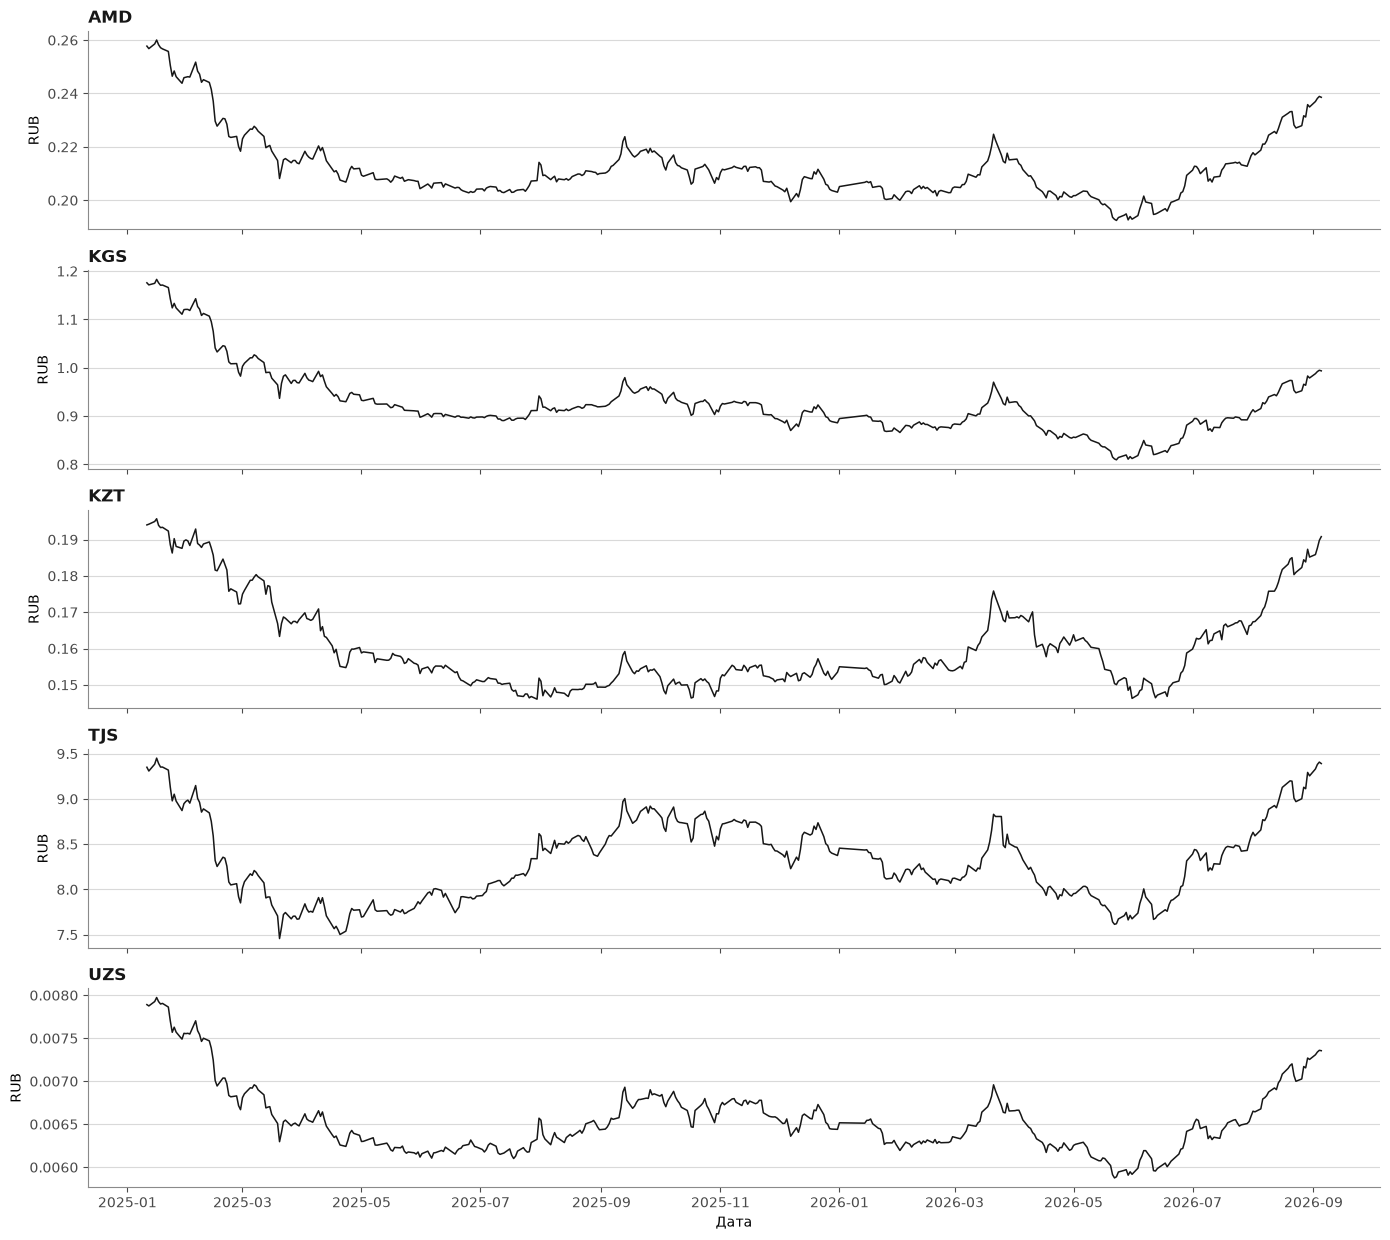

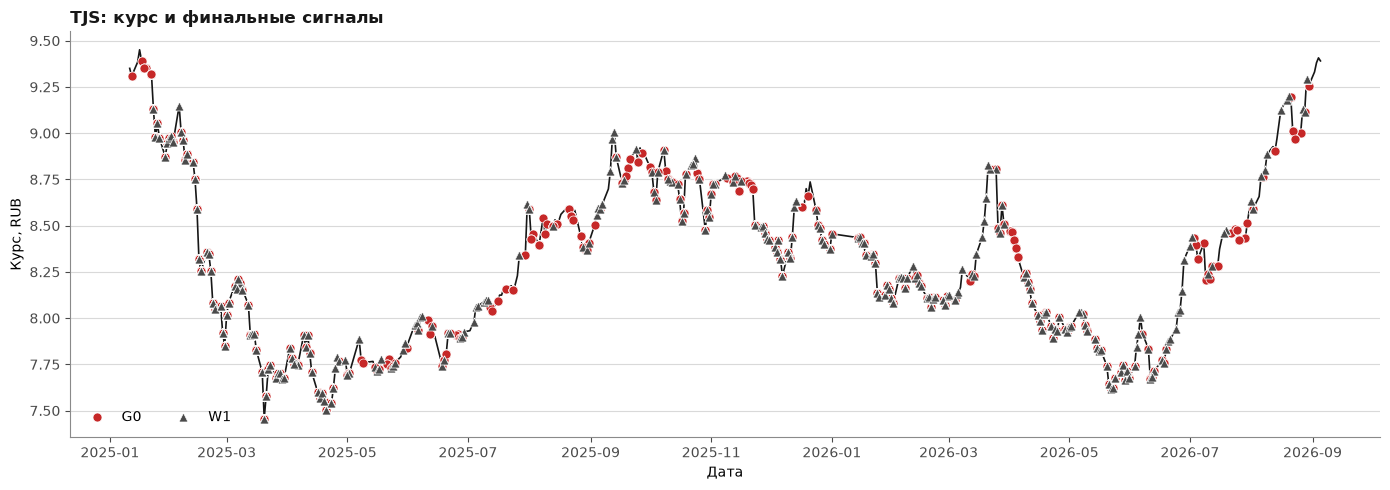

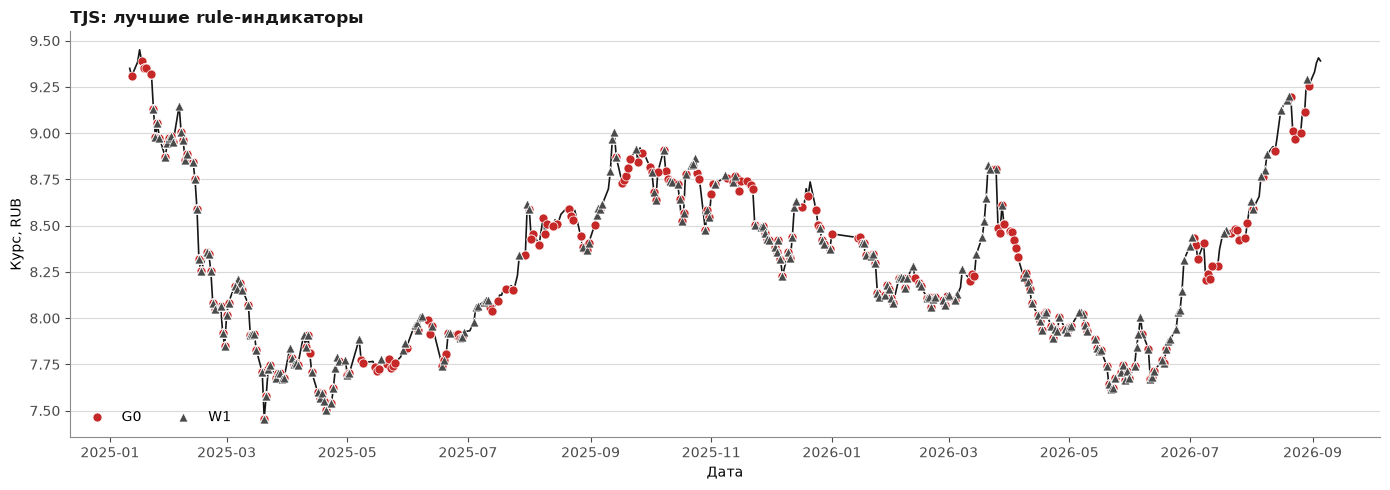

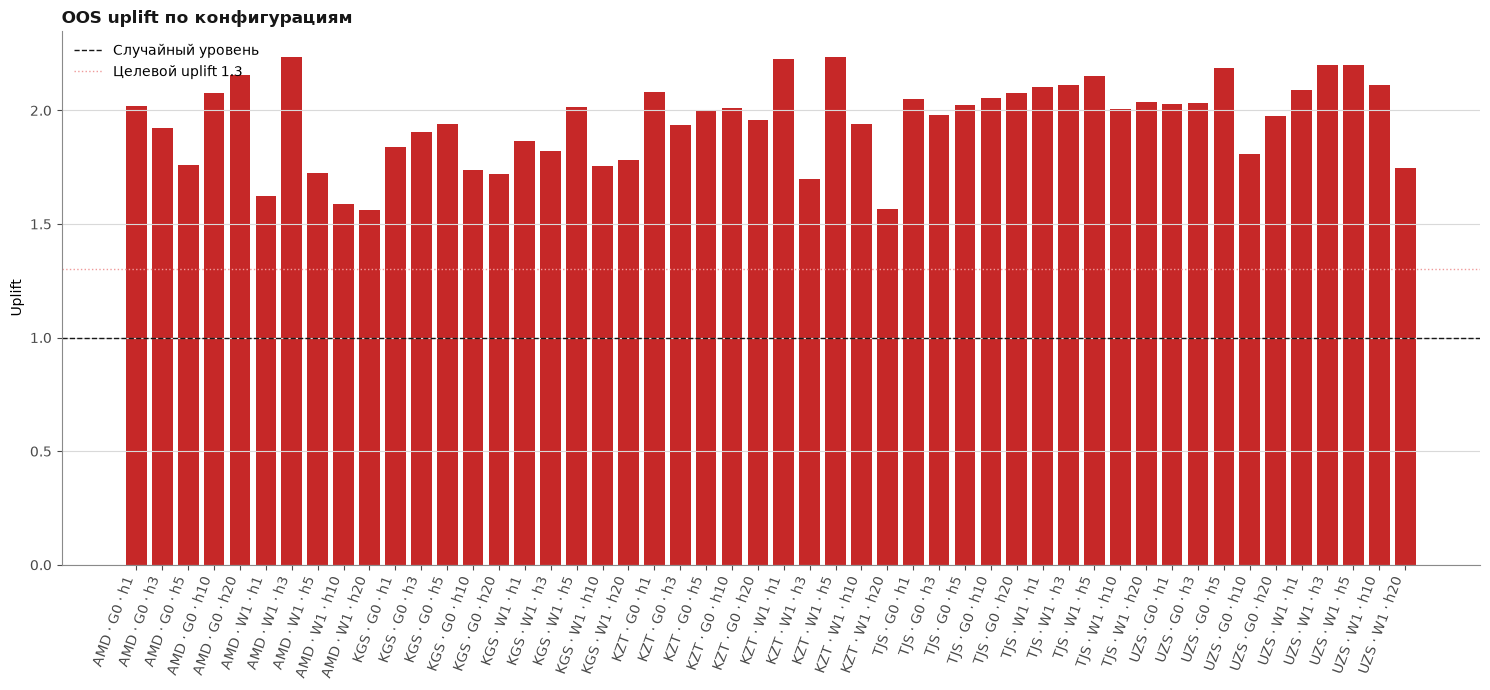

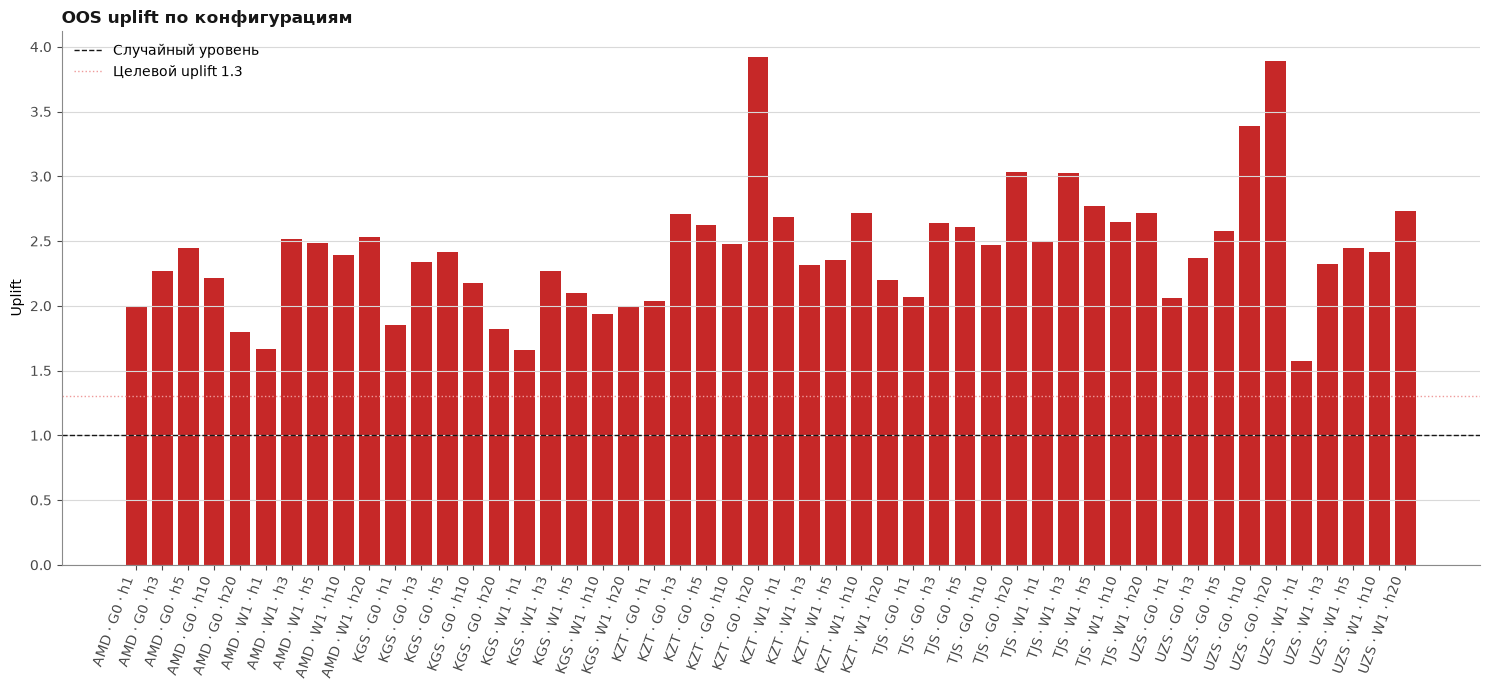

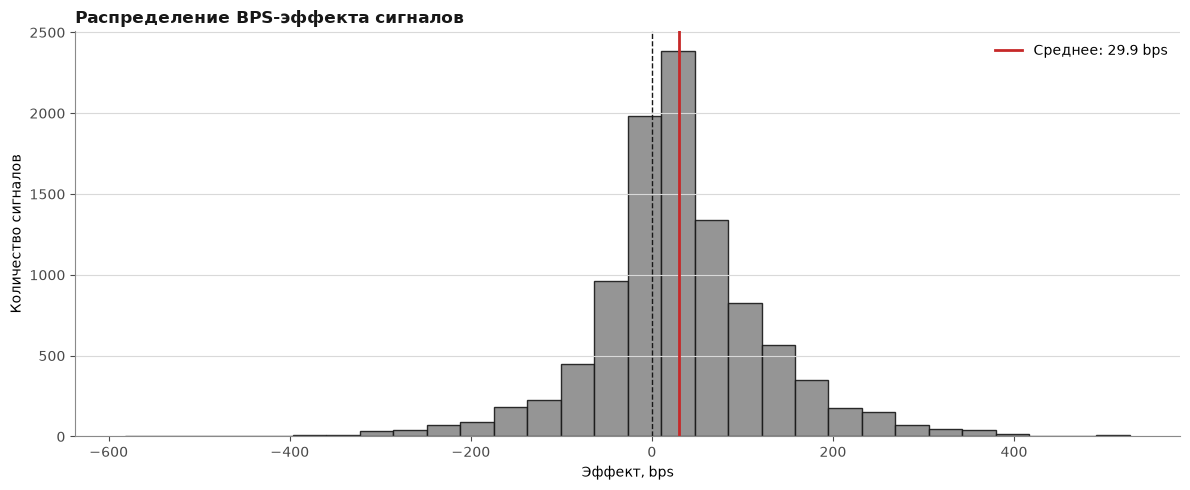

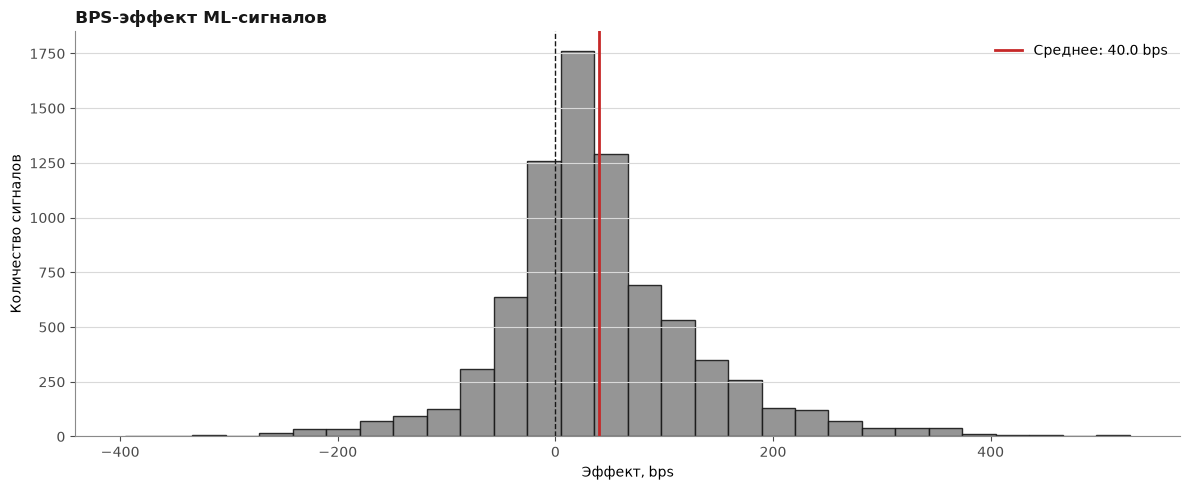

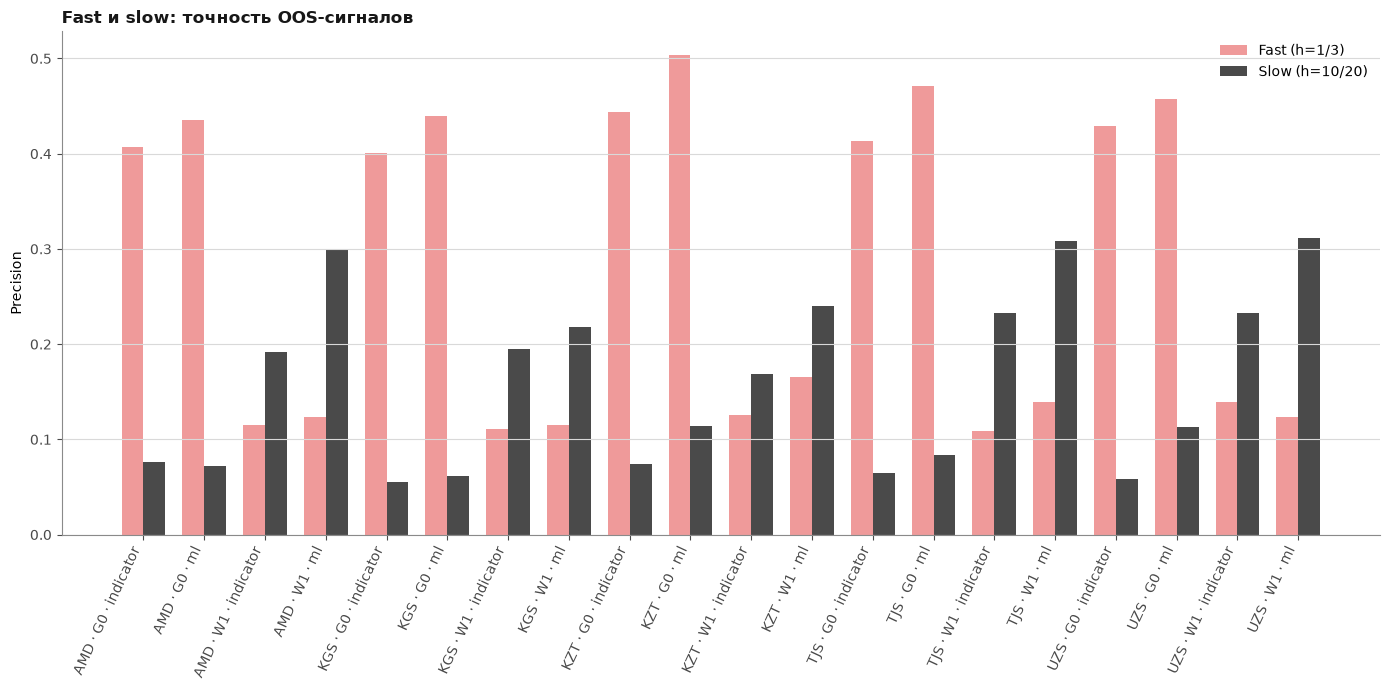

In [14]:
# Отдельная секция графиков для презентации.
import matplotlib.pyplot as plt
PRESENTATION_CURRENCY = 'TJS'
plot_rate_panel(update_rows)
plt.show()

plot_signal_series(
    update_rows,
    pd.concat([final_indicator_backtest_signals, final_ml_backtest_signals], ignore_index=True),
    currency=PRESENTATION_CURRENCY,
    start_date="2025-01-01",
)
plt.tight_layout()
plt.show()

plot_signal_series(
    update_rows, final_indicator_backtest_signals,
    currency=PRESENTATION_CURRENCY, start_date="2025-01-01",
    title=f"{PRESENTATION_CURRENCY}: лучшие rule-индикаторы",
)
plt.tight_layout()
plt.show()

plot_oos_uplift(final_indicator_backtest_summary)
plt.tight_layout()
plt.show()

plot_oos_uplift(final_ml_backtest_summary)
plt.tight_layout()
plt.show()

plot_benefit_distribution(_enrich_signals(final_indicator_backtest_signals))
plt.tight_layout()
plt.show()

plot_benefit_distribution(_enrich_signals(final_ml_backtest_signals), title="BPS-эффект ML-сигналов")
plt.tight_layout()
plt.show()

plot_fast_slow_summary(fast_slow_summary)
plt.tight_layout()
plt.show()